
                 GLIDER POLAR RESULTS

Best-glide condition
Best-glide velocity           = 21.998 m/s
Sink rate at best glide       = 0.721 m/s
Best glide angle              = 1.877 degrees
Maximum glide ratio           = 30.510:1
Theoretical maximum L/D       = 30.510

Minimum-sink condition
Minimum-sink velocity         = 16.715 m/s
Minimum sink rate             = 0.633 m/s


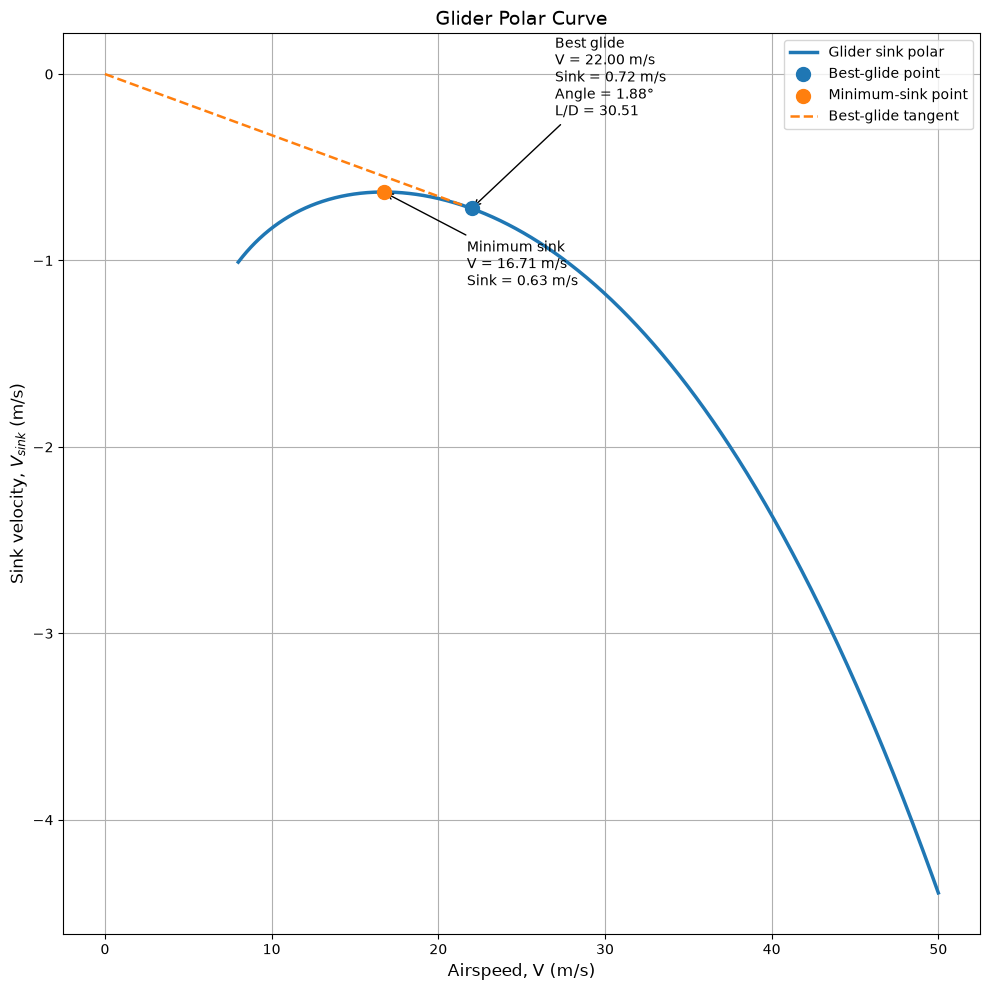

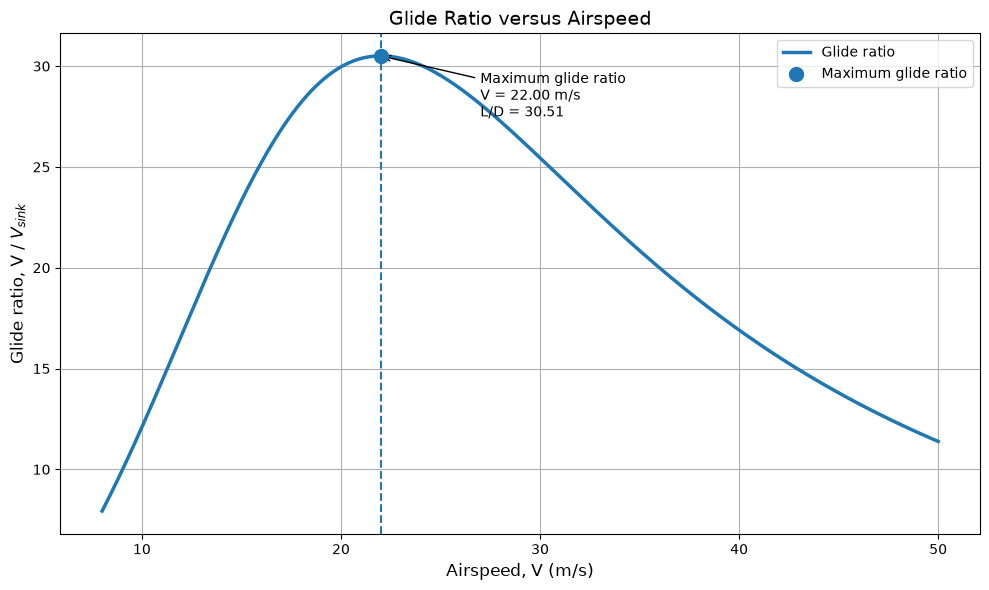

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import math


# ============================================================
#                    USER INPUTS
# ============================================================

rho = 1.225          # Air density, kg/m^3
S = 11.25            # Wing reference area, m^2
CD0 = (0.012+0.015)/2          # Zero-lift drag coefficient
mass = 280           # Aircraft mass, kg
AR = 20              # Wing aspect ratio
e = 0.80             # Oswald efficiency factor
g = 9.81             # Gravitational acceleration, m/s^2

# Airspeed range for plotting
V_min = 8.0          # Minimum plotted velocity, m/s
V_max = 50.0         # Maximum plotted velocity, m/s
number_of_points = 1000


# ============================================================
#                    BASIC CALCULATIONS
# ============================================================

# Convert aircraft mass into weight
W = mass * g         # Weight, N

# Sink-polar coefficients
A = (rho * S * CD0) / (2 * W)

B = (2 * W) / (np.pi * AR * e * rho * S)


# ============================================================
#              ANALYTICAL OPTIMUM VELOCITIES
# ============================================================

# Best-glide velocity:
# Maximum L/D or minimum glide angle
V_best_glide = (B / A) ** 0.25

# Sink rate at best-glide velocity
Vsink_best_glide = (
    A * V_best_glide**3
    + B / V_best_glide
)

# Minimum-sink velocity
V_min_sink = (B / (3 * A)) ** 0.25

# Minimum sink rate
Vsink_minimum = (
    A * V_min_sink**3
    + B / V_min_sink
)


# ============================================================
#                GLIDE ANGLE AND GLIDE RATIO
# ============================================================

# Exact glide angle based on the velocity components
glide_angle_rad = np.arctan(
    Vsink_best_glide / V_best_glide
)

glide_angle_deg = np.degrees(glide_angle_rad)

# Horizontal distance travelled per unit altitude lost
glide_ratio = V_best_glide / Vsink_best_glide

# Theoretical maximum L/D from drag polar
K = 1 / (np.pi * AR * e)

LD_max_theoretical = 1 / (
    2 * np.sqrt(CD0 * K)
)


# ============================================================
#               GENERATE GLIDER POLAR CURVE
# ============================================================

V = np.linspace(V_min, V_max, number_of_points)

Vsink = A * V**3 + B / V

# Glide angle at every velocity
glide_angle = np.degrees(np.arctan(Vsink / V))

# Glide ratio at every velocity
glide_ratio_curve = V / Vsink


# ============================================================
#                    DISPLAY RESULTS
# ============================================================

print("\n" + "=" * 60)
print("                 GLIDER POLAR RESULTS")
print("=" * 60)

# print(f"Aircraft mass                 = {mass:.3f} kg")
# print(f"Aircraft weight               = {W:.3f} N")
# print(f"Wing area                     = {S:.3f} m²")
# print(f"Aspect ratio                  = {AR:.3f}")
# print(f"Oswald efficiency factor      = {e:.3f}")
# print(f"Zero-lift drag coefficient    = {CD0:.5f}")

# print("\nSink-polar coefficients")
# print(f"A coefficient                 = {A:.8e}")
# print(f"B coefficient                 = {B:.8e}")

print("\nBest-glide condition")
print(f"Best-glide velocity           = {V_best_glide:.3f} m/s")
print(f"Sink rate at best glide       = {Vsink_best_glide:.3f} m/s")
print(f"Best glide angle              = {glide_angle_deg:.3f} degrees")
print(f"Maximum glide ratio           = {glide_ratio:.3f}:1")
print(f"Theoretical maximum L/D       = {LD_max_theoretical:.3f}")

print("\nMinimum-sink condition")
print(f"Minimum-sink velocity         = {V_min_sink:.3f} m/s")
print(f"Minimum sink rate             = {Vsink_minimum:.3f} m/s")

print("=" * 60)


# ============================================================
#                   GLIDER POLAR PLOT
# ============================================================

plt.figure(figsize=(10, 10))

plt.plot(
    V,
    -Vsink,
    linewidth=2.5,
    label="Glider sink polar"
)

# Best-glide point
plt.scatter(
    V_best_glide,
    -Vsink_best_glide,
    s=100,
    zorder=5,
    label="Best-glide point"
)

# Minimum-sink point
plt.scatter(
    V_min_sink,
    -Vsink_minimum,
    s=100,
    zorder=5,
    label="Minimum-sink point"
)

# Best-glide tangent line from origin
V_tangent = np.linspace(0, V_best_glide, 100)

tangent_slope = Vsink_best_glide / V_best_glide

Vsink_tangent = tangent_slope * V_tangent

plt.plot(
    V_tangent,
    -Vsink_tangent,
    linestyle="--",
    linewidth=1.8,
    label="Best-glide tangent"
)

# Best-glide annotation
plt.annotate(
    f"Best glide\n"
    f"V = {V_best_glide:.2f} m/s\n"
    f"Sink = {Vsink_best_glide:.2f} m/s\n"
    f"Angle = {glide_angle_deg:.2f}°\n"
    f"L/D = {glide_ratio:.2f}",
    xy=(V_best_glide, -Vsink_best_glide),
    xytext=(V_best_glide + 5, -Vsink_best_glide + 0.5),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

# Minimum-sink annotation
plt.annotate(
    f"Minimum sink\n"
    f"V = {V_min_sink:.2f} m/s\n"
    f"Sink = {Vsink_minimum:.2f} m/s",
    xy=(V_min_sink, -Vsink_minimum),
    xytext=(V_min_sink + 5, -Vsink_minimum - 0.5),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

plt.xlabel("Airspeed, V (m/s)", fontsize=12)
plt.ylabel("Sink velocity, $V_{sink}$ (m/s)", fontsize=12)
plt.title("Glider Polar Curve", fontsize=14)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
#                  GLIDE RATIO PLOT
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    V,
    glide_ratio_curve,
    linewidth=2.5,
    label="Glide ratio"
)

plt.scatter(
    V_best_glide,
    glide_ratio,
    s=100,
    zorder=5,
    label="Maximum glide ratio"
)

plt.axvline(
    V_best_glide,
    linestyle="--",
    linewidth=1.5
)

plt.annotate(
    f"Maximum glide ratio\n"
    f"V = {V_best_glide:.2f} m/s\n"
    f"L/D = {glide_ratio:.2f}",
    xy=(V_best_glide, glide_ratio),
    xytext=(V_best_glide + 5, glide_ratio - 3),
    arrowprops=dict(arrowstyle="->"),
    fontsize=10
)

plt.xlabel("Airspeed, V (m/s)", fontsize=12)
plt.ylabel("Glide ratio, V / $V_{sink}$", fontsize=12)
plt.title("Glide Ratio versus Airspeed", fontsize=14)

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()